In [1]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Reading in Data

In [2]:
data = pd.read_csv("dataset.csv")
data.dtypes

age                 int64
job                object
marital            object
education          object
default             int64
housing             int64
loan                int64
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                   int64
dtype: object

### Variable Extraction

In [3]:
#x-variables to use (excluded: default, housing, duration)
x_vars = ['age', 'job', 'marital', 'education', 'housing', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 
          'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

#extracting x-variables
X = data[x_vars].copy()

#extracting y-variable
y = data['y']

#checking dtypes of x-variables
X.dtypes

age                 int64
job                object
marital            object
education          object
housing             int64
contact            object
month              object
day_of_week        object
campaign            int64
pdays               int64
previous            int64
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
dtype: object

### Data Cleaning

In [4]:
#making 'unknown' a category on its own
X['housing'] = X['housing'].replace(-1, 2)

#categorical x-variables currently as string type
cat_x_vars = ['job', 'marital', 'education', 'housing', 'contact', 'month', 'day_of_week']

#one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                   cat_x_vars)], 
    remainder='passthrough')

### Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
#stratify=y makes sure train/test split keeps same proportion of classes as o.g. data

### Decision Tree (baseline model)

For our baseline decision tree model, we first examined the performance of a basic tree, without hyperparameter tuning. We then built on it and intorduced hyperparameter tuning, which resulted in the performance improving significantly.

#### 1. Decision Tree without hypermarameter tuning (to see baseline performance first)

In [6]:
#SMOTE for oversampling minority class (helps with highly unbalanced data)
smote = SMOTE(random_state=42)

#pipeline with SMOTE
dt_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [7]:
#baseline model with default hyperparameters
dt_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given 

In [8]:
#predictions
y_pred = dt_pipeline.predict(X_test)

#evaluation
print("Class 1 F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Class 1 F1-score: 0.34279918864097364

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      7310
           1       0.32      0.36      0.34       928

    accuracy                           0.84      8238
   macro avg       0.62      0.63      0.63      8238
weighted avg       0.85      0.84      0.85      8238



#### 2. Decision Tree with hyperparameter tuning

In [9]:
#defining list of values to search within
param_grid = {
    'classifier__max_depth': [4, 5, 6, 7, 8],
    #this alone increase f1 score significantly, suggesting baseline tree was overfitted, as there was no limit to max_depth
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4, 5],
    'classifier__criterion': ['gini', 'entropy']
}

#hyperparameter tuning
grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,             # 5-fold cross-validation
    scoring='f1',     # evaluation metric
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
Best CV F1: 0.47062292655752513


### Tree plotting (first 3 levels)

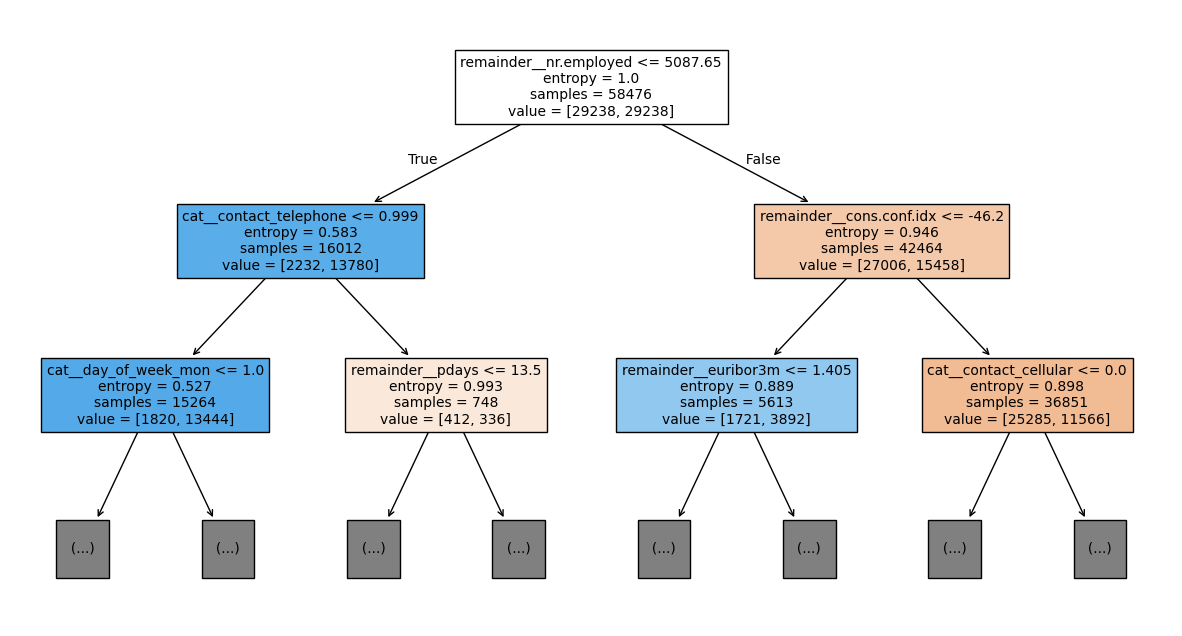

In [10]:
#extract the best fitted classifier
best_pipeline = grid_search.best_estimator_
best_tree = best_pipeline.named_steps['classifier']

#getting feature names for plotting tree
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
#print(feature_names)

plt.figure(figsize=(15,8))
plot_tree(best_tree, feature_names=feature_names, filled=True, max_depth=2, fontsize=10)
plt.show()

### Feature Importance

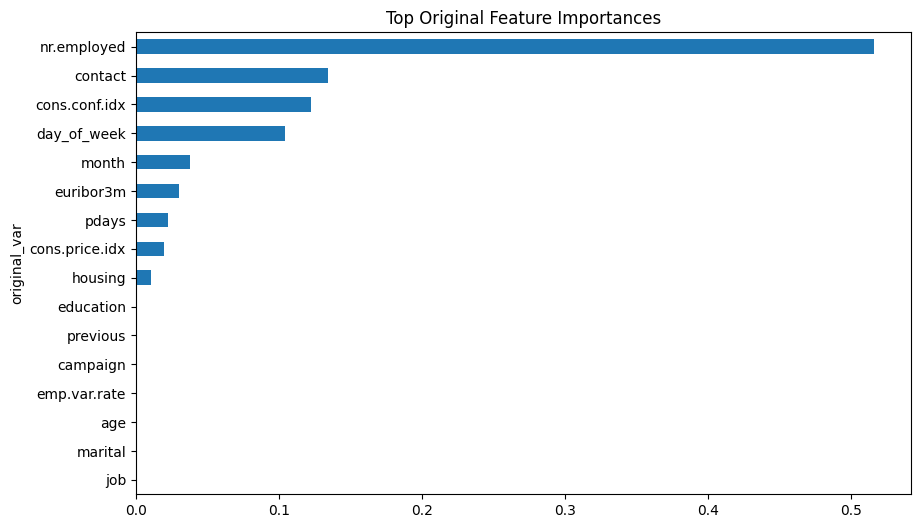

In [11]:
#map each dummy to its original variable
dummy_to_original = {}
for orig in x_vars:
    for fn in feature_names:
        # Check if the original variable is anywhere in the feature name
        if orig in fn:
            dummy_to_original[fn] = orig

#create DataFrame with importances
importances = best_tree.feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

#map to original variable
fi_df['original_var'] = fi_df['feature'].map(dummy_to_original)

#sum importances for each original variable
fi_agg = fi_df.groupby('original_var')['importance'].sum().sort_values(ascending=False)

#plot in order of importance
plt.figure(figsize=(10,6))
fi_agg[:].plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Original Feature Importances")
plt.show()

### Model Testing & Performance Evaluation

In [12]:
y_pred = grid_search.predict(X_test)

f1 = f1_score(y_test, y_pred)

print("Class 1 F1-score:", f1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Class 1 F1-score: 0.5099685204616999

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94      7310
           1       0.50      0.52      0.51       928

    accuracy                           0.89      8238
   macro avg       0.72      0.73      0.72      8238
weighted avg       0.89      0.89      0.89      8238



### XGBoost Model

We now move on to a more complex model, namely XGBoost. XGBoost builds many trees, one after another. Each new tree tries to fix the mistakes of all previous trees, thus it usually performs better than the baseline tree.

As total computational time can be very long if we were to perform tuning for all hyperparamaters together, we splitted the tuning stage into 2 stages.

#### Stage 1: Coarse tuning

In [13]:
#preprocessor
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                   cat_x_vars)], 
    remainder='passthrough')

#pipeline
xgb_pipeline_top = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

#stage 1 hyperparameters
param_grid_stage1 = {
    'classifier__max_depth': [4, 5, 6],
    'classifier__learning_rate': [0.01, 0.02, 0.05],
    'classifier__n_estimators': [50, 100, 200]
}

grid_search_stage1 = GridSearchCV(
    xgb_pipeline_top,
    param_grid_stage1,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_stage1.fit(X_train, y_train)

print("Stage 1 best params:", grid_search_stage1.best_params_)
print("Stage 1 best CV F1:", grid_search_stage1.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Stage 1 best params: {'classifier__learning_rate': 0.02, 'classifier__max_depth': 6, 'classifier__n_estimators': 50}
Stage 1 best CV F1: 0.4870570488891463


#### Stage 2: Fine-tuning

In [14]:
best_stage1 = grid_search_stage1.best_params_

#stage 1 best params
xgb_pipeline_top.set_params(
    classifier__max_depth=best_stage1['classifier__max_depth'],
    classifier__learning_rate=best_stage1['classifier__learning_rate'],
    classifier__n_estimators=best_stage1['classifier__n_estimators']
)

#stage 2 hyperparameters
param_grid_stage2 = {
    'classifier__subsample': [0.7, 0.8, 1],
    'classifier__colsample_bytree': [0.7, 0.8, 1],
    'classifier__gamma': [0, 0.1, 0.2],
    'classifier__reg_lambda': [1, 5, 10]
}

grid_search_stage2 = GridSearchCV(
    xgb_pipeline_top,
    param_grid_stage2,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_stage2.fit(X_train, y_train)
best_stage2 = grid_search_stage2.best_params_

print("\nStage 2 best params (with randomness tuned):", best_stage2)
print("Stage 2 best CV F1:", grid_search_stage2.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Stage 2 best params (with randomness tuned): {'classifier__colsample_bytree': 1, 'classifier__gamma': 0, 'classifier__reg_lambda': 10, 'classifier__subsample': 0.8}
Stage 2 best CV F1: 0.4900337297106505


### Model Testing & Performance Evaluation

In [15]:
y_pred = grid_search_stage2.predict(X_test)

print("\nF1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


F1-score: 0.521175884404584

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93      7310
           1       0.48      0.56      0.52       928

    accuracy                           0.88      8238
   macro avg       0.71      0.74      0.73      8238
weighted avg       0.89      0.88      0.89      8238



### Feature Importance

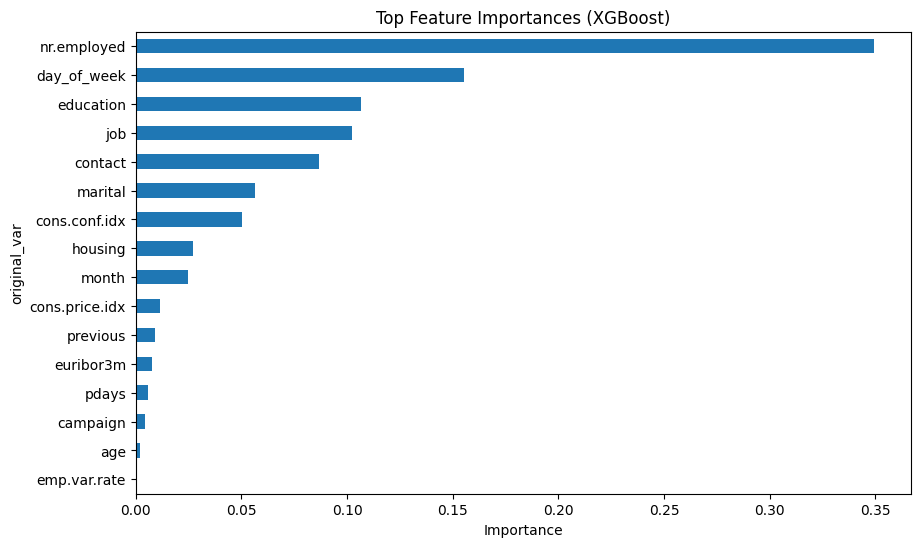

In [16]:
#extract pipeline and classifier
best_pipeline = grid_search_stage2.best_estimator_
best_tree = best_pipeline.named_steps['classifier']

#get feature names
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

#get importances
importances = best_tree.feature_importances_

#map dummies back to original variables
dummy_to_original = {}
for orig in x_vars:
    for fn in feature_names:
        if orig in fn:
            dummy_to_original[fn] = orig

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
fi_df['original_var'] = fi_df['feature'].map(dummy_to_original)

#aggregate importance by original variable
fi_agg = fi_df.groupby('original_var')['importance'].sum().sort_values(ascending=False)

#plot top features
plt.figure(figsize=(10,6))
fi_agg[:].plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()